# Projeto G1 — Análise da Cobertura Vacinal no Brasil

**Disciplina:** Linguagem de Programação — Análise e Visualização de Dados com Python  
**Tema:** Cobertura Vacinal no Brasil  
**Base:** `simulacao_cobertura_vacinal_brasil.csv`

> **Importante:** a base fornecida para a atividade é uma **simulação**. As conclusões deste notebook descrevem apenas esse conjunto de dados e não representam estatísticas oficiais de saúde pública.

Antes de executar o notebook, coloque o arquivo `simulacao_cobertura_vacinal_brasil.csv` na **raiz do ambiente do Google Colab**, normalmente em `/content/`.

## 1. Preparação do ambiente e leitura da base

O notebook espera que o arquivo CSV já esteja disponível na raiz do Colab.

Estrutura esperada:

```text
/content/
└── simulacao_cobertura_vacinal_brasil.csv
```

Não é necessário usar `files.upload()` dentro do notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Evita notação científica nas tabelas.
pd.options.display.float_format = "{:,.2f}".format

ARQUIVO = Path("/content/simulacao_cobertura_vacinal_brasil.csv")

if not ARQUIVO.exists():
    raise FileNotFoundError(
        "Arquivo não encontrado. Coloque "
        "'simulacao_cobertura_vacinal_brasil.csv' "
        "na raiz do Colab (/content/) e execute novamente."
    )

df = pd.read_csv(ARQUIVO)

print("Base carregada com sucesso.")
print(f"Arquivo: {ARQUIVO}")
print(f"Linhas: {len(df):,}".replace(",", "."))
print(f"Colunas: {df.shape[1]}")

display(df.head())

Base carregada com sucesso.
Arquivo: /content/simulacao_cobertura_vacinal_brasil.csv
Linhas: 4.440
Colunas: 14


,ano,mes,data,regiao,uf,municipio,vacina,doses_aplicadas,publico_alvo,cobertura_percentual,meta_percentual,populacao_alvo,campanhas,nivel_alerta
0,2015,1,2015-01-01,Norte,AM,Manaus,Poliomielite,292274,Adultos,58.72,80,497714,0,Crítico
1,2015,1,2015-01-01,Norte,PA,Belém,BCG,181341,Adultos,81.73,80,221885,0,Adequado
2,2015,1,2015-01-01,Norte,PA,Santarém,Influenza,46148,Crianças,69.03,80,66849,3,Atenção
3,2015,1,2015-01-01,Norte,RO,Porto Velho,Hepatite B,22357,Idosos,75.64,95,29558,0,Crítico
4,2015,1,2015-01-01,Norte,TO,Palmas,COVID-19,393777,Gestantes,86.57,95,454876,4,Atenção


## 2. Introdução ao problema

A cobertura vacinal é um indicador utilizado para acompanhar o alcance das ações de imunização em diferentes grupos da população.

O objetivo deste projeto é explorar uma base simulada de cobertura vacinal no Brasil e responder perguntas como:

- Como a cobertura percentual evolui ao longo do tempo?
- Existem diferenças entre as regiões brasileiras?
- Quais vacinas apresentam maior e menor cobertura média?
- Qual proporção dos registros atinge a meta definida?
- Como os registros se distribuem entre os níveis **Adequado**, **Atenção** e **Crítico**?
- Existe associação linear entre cobertura, quantidade de campanhas, doses aplicadas e população-alvo?

A análise utiliza **Python**, **Pandas**, **Matplotlib** e **Seaborn**. Os dados tratados também poderão ser reaproveitados no dashboard em **Streamlit**.

## 3. Explicação da base de dados

A base contém **4.440 registros** e **14 colunas**, com informações mensais entre **2015 e 2024**.

| Coluna | Descrição |
|---|---|
| `ano` | Ano do registro |
| `mes` | Mês do registro |
| `data` | Data de referência |
| `regiao` | Região do Brasil |
| `uf` | Unidade Federativa |
| `municipio` | Município |
| `vacina` | Nome da vacina |
| `doses_aplicadas` | Quantidade de doses aplicadas |
| `publico_alvo` | Grupo populacional |
| `cobertura_percentual` | Percentual de cobertura |
| `meta_percentual` | Meta percentual definida |
| `populacao_alvo` | Tamanho da população-alvo |
| `campanhas` | Quantidade de campanhas |
| `nivel_alerta` | Classificação do registro |

## 4. Inspeção e qualidade dos dados

Os resumos numérico e categórico são apresentados separadamente.

Isso evita confusão com os `NaN` que aparecem em `describe(include="all")` quando o Pandas mistura estatísticas numéricas e textuais na mesma tabela.

In [2]:
print("Tipos das colunas:")

display(
    pd.DataFrame({
        "coluna": df.columns,
        "tipo": df.dtypes.astype(str).values
    })
)

Tipos das colunas:


,coluna,tipo
0,ano,int64
1,mes,int64
2,data,object
3,regiao,object
4,uf,object
5,municipio,object
6,vacina,object
7,doses_aplicadas,int64
8,publico_alvo,object
9,cobertura_percentual,float64


### 4.1 Valores ausentes

In [3]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "valores_ausentes": df.isna().sum(),
    "percentual_ausente": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique(dropna=False)
})

display(qualidade)

print(f"Total de valores ausentes na base: {int(df.isna().sum().sum())}")

,tipo,valores_ausentes,percentual_ausente,valores_unicos
ano,int64,0,0.00,10
mes,int64,0,0.00,12
data,object,0,0.00,120
regiao,object,0,0.00,5
uf,object,0,0.00,20
municipio,object,0,0.00,37
vacina,object,0,0.00,6
doses_aplicadas,int64,0,0.00,4420
publico_alvo,object,0,0.00,5
cobertura_percentual,float64,0,0.00,2384


Total de valores ausentes na base: 0


### 4.2 Duplicidades

In [4]:
duplicadas = int(df.duplicated().sum())

print(f"Linhas duplicadas: {duplicadas}")

df = df.drop_duplicates().copy()

Linhas duplicadas: 0


### 4.3 Resumo das variáveis numéricas

Os valores de `doses_aplicadas` e `populacao_alvo` são quantidades absolutas. Por isso, podem aparecer valores altos.

A formatação utilizada evita notação científica.

In [5]:
colunas_numericas = [
    "ano",
    "mes",
    "doses_aplicadas",
    "cobertura_percentual",
    "meta_percentual",
    "populacao_alvo",
    "campanhas"
]

resumo_numerico = (
    df[colunas_numericas]
    .describe()
    .T
    .round(2)
)

display(resumo_numerico)

,count,mean,std,min,25%,50%,75%,max
ano,"4,440.00","2,019.50",2.87,"2,015.00","2,017.00","2,019.50","2,022.00","2,024.00"
mes,"4,440.00",6.50,3.45,1.00,3.75,6.50,9.25,12.00
doses_aplicadas,"4,440.00","214,186.43","121,767.48","7,356.00","110,325.25","211,400.50","311,387.00","498,550.00"
cobertura_percentual,"4,440.00",84.00,9.59,46.97,77.53,84.31,90.94,100.00
meta_percentual,"4,440.00",89.12,7.32,80.00,80.00,95.00,95.00,95.00
populacao_alvo,"4,440.00","254,980.21","140,931.95","10,152.00","134,279.75","256,965.00","377,522.50","499,964.00"
campanhas,"4,440.00",0.99,0.99,0.00,0.00,1.00,2.00,6.00


### 4.4 Resumo das variáveis categóricas

In [6]:
colunas_categoricas = [
    "data",
    "regiao",
    "uf",
    "municipio",
    "vacina",
    "publico_alvo",
    "nivel_alerta"
]

resumo_categorico = (
    df[colunas_categoricas]
    .describe()
    .T
)

display(resumo_categorico)

,count,unique,top,freq
data,4440,120,2015-01-01,37
regiao,4440,5,Sudeste,1560
uf,4440,20,RJ,480
municipio,4440,37,Manaus,120
vacina,4440,6,Poliomielite,782
publico_alvo,4440,5,Gestantes,919
nivel_alerta,4440,3,Atenção,1936


## 5. Limpeza e preparação

Nesta etapa serão realizados:

1. conversão da data;
2. conversão explícita das variáveis numéricas;
3. remoção de espaços extras em textos;
4. validação de intervalos;
5. verificação de consistência entre doses, população e cobertura.

In [7]:
df["data"] = pd.to_datetime(df["data"], errors="coerce")

colunas_numericas_tratamento = [
    "ano",
    "mes",
    "doses_aplicadas",
    "cobertura_percentual",
    "meta_percentual",
    "populacao_alvo",
    "campanhas"
]

for coluna in colunas_numericas_tratamento:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

colunas_texto = [
    "regiao",
    "uf",
    "municipio",
    "vacina",
    "publico_alvo",
    "nivel_alerta"
]

for coluna in colunas_texto:
    df[coluna] = (
        df[coluna]
        .astype("string")
        .str.strip()
    )

print("Tratamento básico concluído.")

Tratamento básico concluído.


### 5.1 Validação de intervalos

In [8]:
validacoes = pd.DataFrame({
    "verificacao": [
        "Datas inválidas",
        "Cobertura abaixo de 0%",
        "Cobertura acima de 100%",
        "Meta abaixo de 0%",
        "Meta acima de 100%",
        "Doses negativas",
        "População-alvo menor ou igual a zero",
        "Campanhas negativas"
    ],
    "ocorrencias": [
        df["data"].isna().sum(),
        (df["cobertura_percentual"] < 0).sum(),
        (df["cobertura_percentual"] > 100).sum(),
        (df["meta_percentual"] < 0).sum(),
        (df["meta_percentual"] > 100).sum(),
        (df["doses_aplicadas"] < 0).sum(),
        (df["populacao_alvo"] <= 0).sum(),
        (df["campanhas"] < 0).sum()
    ]
})

display(validacoes)

,verificacao,ocorrencias
0,Datas inválidas,0
1,Cobertura abaixo de 0%,0
2,Cobertura acima de 100%,0
3,Meta abaixo de 0%,0
4,Meta acima de 100%,0
5,Doses negativas,0
6,População-alvo menor ou igual a zero,0
7,Campanhas negativas,0


### 5.2 Consistência entre doses, população-alvo e cobertura

A cobertura percentual da base pode ser conferida aproximadamente pela relação:

```text
cobertura = doses_aplicadas / populacao_alvo × 100
```

Pequenas diferenças podem ocorrer por arredondamento.

In [9]:
df["cobertura_calculada"] = (
    df["doses_aplicadas"] /
    df["populacao_alvo"] * 100
)

df["erro_cobertura"] = (
    df["cobertura_calculada"] -
    df["cobertura_percentual"]
).abs()

print(
    "Maior diferença entre cobertura informada e calculada:",
    f"{df['erro_cobertura'].max():.4f} ponto percentual"
)

display(
    df[
        [
            "doses_aplicadas",
            "populacao_alvo",
            "cobertura_percentual",
            "cobertura_calculada",
            "erro_cobertura"
        ]
    ].head()
)

Maior diferença entre cobertura informada e calculada: 0.0114 ponto percentual


,doses_aplicadas,populacao_alvo,cobertura_percentual,cobertura_calculada,erro_cobertura
0,292274,497714,58.72,58.72,0.00
1,181341,221885,81.73,81.73,0.00
2,46148,66849,69.03,69.03,0.00
3,22357,29558,75.64,75.64,0.00
4,393777,454876,86.57,86.57,0.00


### 5.3 Resultado da limpeza

Depois das verificações, as colunas auxiliares de validação são removidas.

In [10]:
df = df.drop(
    columns=["cobertura_calculada", "erro_cobertura"]
)

print(f"Base final para análise: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Valores ausentes após tratamento: {int(df.isna().sum().sum())}")

Base final para análise: 4440 linhas x 14 colunas
Valores ausentes após tratamento: 0


## 6. Engenharia de atributos

Serão criadas variáveis derivadas para facilitar a análise:

- `gap_meta`: diferença entre cobertura e meta;
- `atingiu_meta`: indica se a meta foi atingida;
- `ano_mes`: referência mensal;
- `trimestre`: trimestre do registro;
- `faixa_cobertura`: faixa percentual da cobertura.

In [11]:
df["gap_meta"] = (
    df["cobertura_percentual"] -
    df["meta_percentual"]
)

df["atingiu_meta"] = (
    df["cobertura_percentual"] >=
    df["meta_percentual"]
)

df["ano_mes"] = (
    df["data"]
    .dt.to_period("M")
    .astype(str)
)

df["trimestre"] = (
    df["data"]
    .dt.to_period("Q")
    .astype(str)
)

df["faixa_cobertura"] = pd.cut(
    df["cobertura_percentual"],
    bins=[0, 70, 80, 90, 100],
    labels=[
        "Abaixo de 70%",
        "70% a 79,9%",
        "80% a 89,9%",
        "90% a 100%"
    ],
    include_lowest=True
)

display(
    df[
        [
            "data",
            "regiao",
            "vacina",
            "cobertura_percentual",
            "meta_percentual",
            "gap_meta",
            "atingiu_meta",
            "faixa_cobertura"
        ]
    ].head()
)

,data,regiao,vacina,cobertura_percentual,meta_percentual,gap_meta,atingiu_meta,faixa_cobertura
0,2015-01-01,Norte,Poliomielite,58.72,80,-21.28,False,Abaixo de 70%
1,2015-01-01,Norte,BCG,81.73,80,1.73,True,"80% a 89,9%"
2,2015-01-01,Norte,Influenza,69.03,80,-10.97,False,Abaixo de 70%
3,2015-01-01,Norte,Hepatite B,75.64,95,-19.36,False,"70% a 79,9%"
4,2015-01-01,Norte,COVID-19,86.57,95,-8.43,False,"80% a 89,9%"


## 7. Análise exploratória

In [12]:
print(f"Período: {df['data'].min().date()} até {df['data'].max().date()}")
print(f"Regiões: {df['regiao'].nunique()}")
print(f"UFs: {df['uf'].nunique()}")
print(f"Municípios: {df['municipio'].nunique()}")
print(f"Vacinas: {df['vacina'].nunique()}")
print(f"Públicos-alvo: {df['publico_alvo'].nunique()}")

Período: 2015-01-01 até 2024-12-01
Regiões: 5
UFs: 20
Municípios: 37
Vacinas: 6
Públicos-alvo: 5


### 7.1 Quantidade de registros por região

In [13]:
registros_regiao = (
    df["regiao"]
    .value_counts()
    .rename_axis("regiao")
    .reset_index(name="registros")
)

display(registros_regiao)

,regiao,registros
0,Sudeste,1560
1,Nordeste,960
2,Sul,720
3,Norte,600
4,Centro-Oeste,600


### 7.2 Quantidade de registros por vacina

In [14]:
registros_vacina = (
    df["vacina"]
    .value_counts()
    .rename_axis("vacina")
    .reset_index(name="registros")
)

display(registros_vacina)

,vacina,registros
0,Poliomielite,782
1,Influenza,769
2,BCG,760
3,Hepatite B,721
4,Tríplice Viral,713
5,COVID-19,695


### 7.3 Níveis de alerta

In [15]:
alertas = (
    df["nivel_alerta"]
    .value_counts()
    .rename_axis("nivel_alerta")
    .reset_index(name="registros")
)

alertas["percentual"] = (
    alertas["registros"] /
    len(df) * 100
).round(2)

display(alertas)

,nivel_alerta,registros,percentual
0,Atenção,1936,43.60
1,Adequado,1543,34.75
2,Crítico,961,21.64


## 8. KPIs

In [16]:
kpis = pd.DataFrame({
    "Indicador": [
        "Total de registros",
        "Cobertura média",
        "Mediana da cobertura",
        "Meta média",
        "Maior cobertura",
        "Menor cobertura",
        "Registros que atingiram a meta",
        "Doses aplicadas"
    ],
    "Valor": [
        f"{len(df):,.0f}".replace(",", "."),
        f"{df['cobertura_percentual'].mean():.2f}%",
        f"{df['cobertura_percentual'].median():.2f}%",
        f"{df['meta_percentual'].mean():.2f}%",
        f"{df['cobertura_percentual'].max():.2f}%",
        f"{df['cobertura_percentual'].min():.2f}%",
        f"{df['atingiu_meta'].mean() * 100:.2f}%",
        f"{df['doses_aplicadas'].sum():,.0f}".replace(",", ".")
    ]
})

display(kpis)

,Indicador,Valor
0,Total de registros,4.440
1,Cobertura média,84.00%
2,Mediana da cobertura,84.31%
3,Meta média,89.12%
4,Maior cobertura,100.00%
5,Menor cobertura,46.97%
6,Registros que atingiram a meta,34.75%
7,Doses aplicadas,950.987.728


> **Observação:** o total de doses é a soma dos registros da base ao longo de vários anos, localidades, vacinas e públicos-alvo. Não representa quantidade de pessoas distintas.

### 8.1 KPIs por região

In [17]:
kpi_regiao = (
    df.groupby("regiao")
      .agg(
          cobertura_media=("cobertura_percentual", "mean"),
          cobertura_mediana=("cobertura_percentual", "median"),
          registros=("cobertura_percentual", "size"),
          taxa_atingiu_meta=("atingiu_meta", "mean")
      )
      .reset_index()
)

kpi_regiao["taxa_atingiu_meta"] *= 100

kpi_regiao = (
    kpi_regiao
    .sort_values("cobertura_media", ascending=False)
    .round(2)
)

display(kpi_regiao)

,regiao,cobertura_media,cobertura_mediana,registros,taxa_atingiu_meta
4,Sul,84.77,84.68,720,35.56
2,Norte,84.16,85.12,600,34.33
0,Centro-Oeste,83.95,84.10,600,37.50
1,Nordeste,83.79,83.80,960,35.52
3,Sudeste,83.74,84.25,1560,33.01


## 9. Gráficos

### 9.1 Distribuição da cobertura percentual

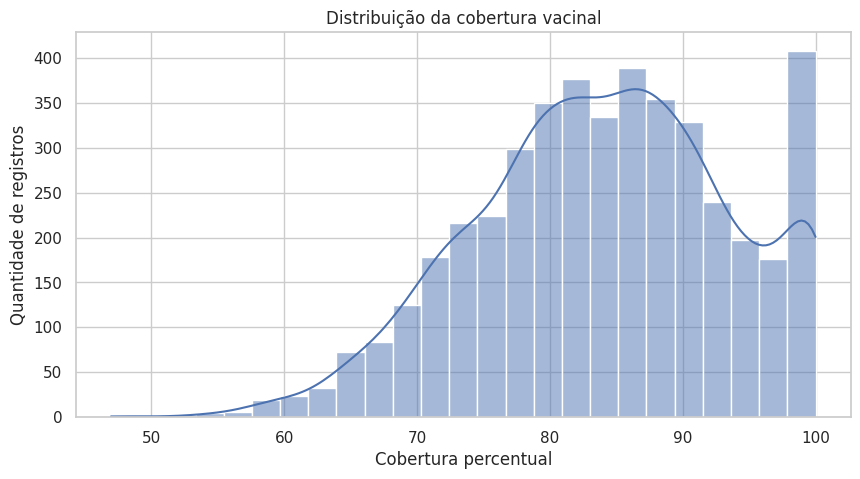

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="cobertura_percentual",
    bins=25,
    kde=True
)

plt.title("Distribuição da cobertura vacinal")
plt.xlabel("Cobertura percentual")
plt.ylabel("Quantidade de registros")
plt.show()

### 9.2 Cobertura média por região

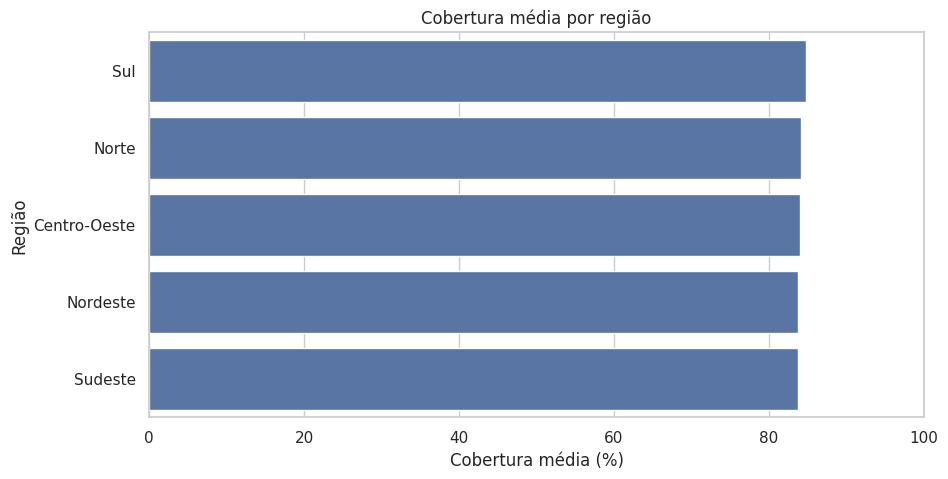

In [19]:
media_regiao = (
    df.groupby("regiao", as_index=False)["cobertura_percentual"]
      .mean()
      .sort_values("cobertura_percentual", ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=media_regiao,
    x="cobertura_percentual",
    y="regiao"
)

plt.title("Cobertura média por região")
plt.xlabel("Cobertura média (%)")
plt.ylabel("Região")
plt.xlim(0, 100)
plt.show()

### 9.3 Cobertura média por vacina

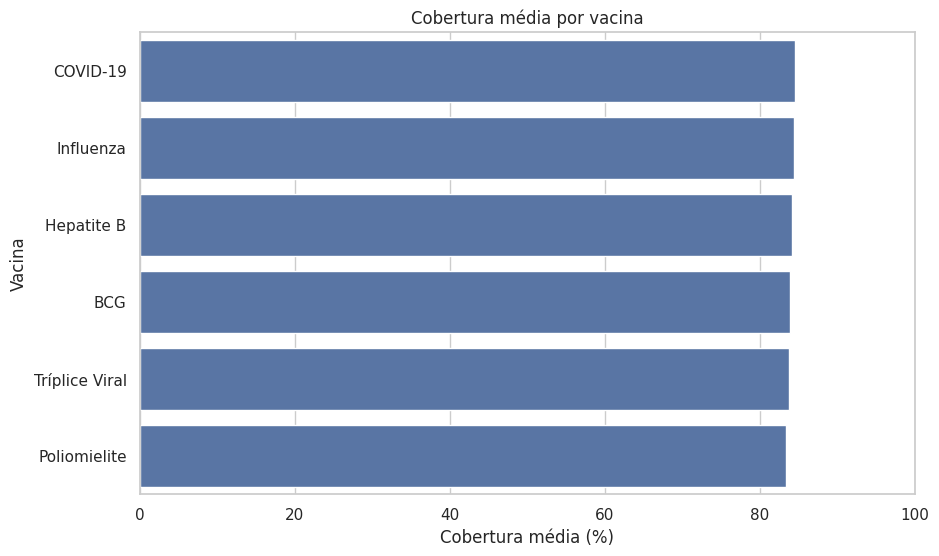

In [20]:
media_vacina = (
    df.groupby("vacina", as_index=False)["cobertura_percentual"]
      .mean()
      .sort_values("cobertura_percentual", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=media_vacina,
    x="cobertura_percentual",
    y="vacina"
)

plt.title("Cobertura média por vacina")
plt.xlabel("Cobertura média (%)")
plt.ylabel("Vacina")
plt.xlim(0, 100)
plt.show()

### 9.4 Evolução anual da cobertura

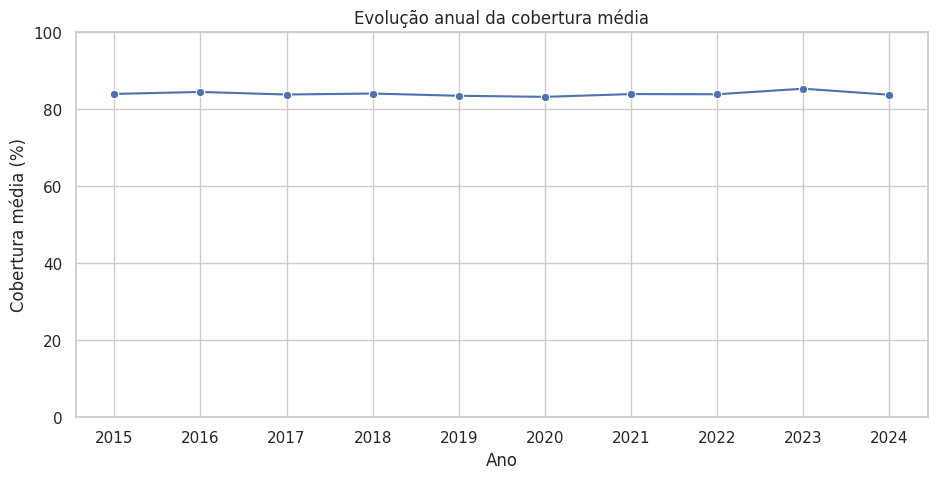

In [21]:
media_ano = (
    df.groupby("ano", as_index=False)["cobertura_percentual"]
      .mean()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    data=media_ano,
    x="ano",
    y="cobertura_percentual",
    marker="o"
)

plt.title("Evolução anual da cobertura média")
plt.xlabel("Ano")
plt.ylabel("Cobertura média (%)")
plt.ylim(0, 100)
plt.xticks(media_ano["ano"])
plt.show()

### 9.5 Série temporal mensal com média móvel

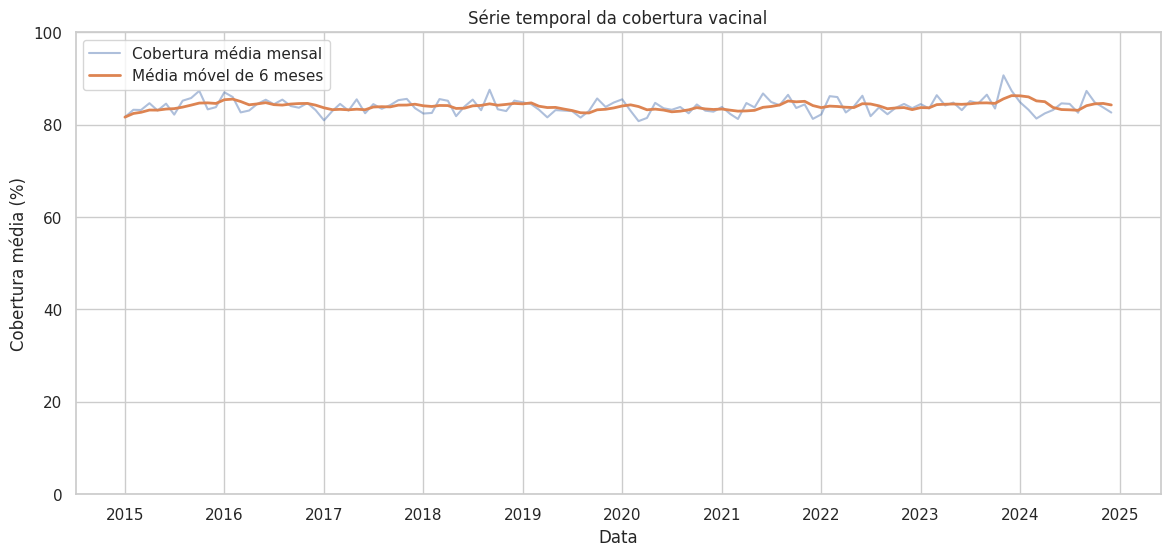

In [22]:
serie_mensal = (
    df.groupby("data", as_index=False)["cobertura_percentual"]
      .mean()
      .sort_values("data")
)

serie_mensal["media_movel_6m"] = (
    serie_mensal["cobertura_percentual"]
    .rolling(window=6, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    serie_mensal["data"],
    serie_mensal["cobertura_percentual"],
    alpha=0.45,
    label="Cobertura média mensal"
)

plt.plot(
    serie_mensal["data"],
    serie_mensal["media_movel_6m"],
    linewidth=2,
    label="Média móvel de 6 meses"
)

plt.title("Série temporal da cobertura vacinal")
plt.xlabel("Data")
plt.ylabel("Cobertura média (%)")
plt.ylim(0, 100)
plt.legend()
plt.show()

### 9.6 Níveis de alerta

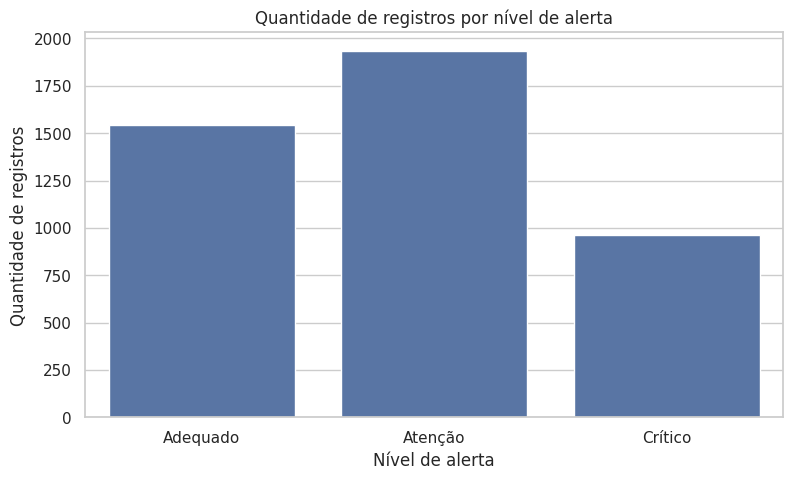

In [23]:
ordem_alerta = ["Adequado", "Atenção", "Crítico"]

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="nivel_alerta",
    order=ordem_alerta
)

plt.title("Quantidade de registros por nível de alerta")
plt.xlabel("Nível de alerta")
plt.ylabel("Quantidade de registros")
plt.show()

### 9.7 Cobertura média x meta média por vacina

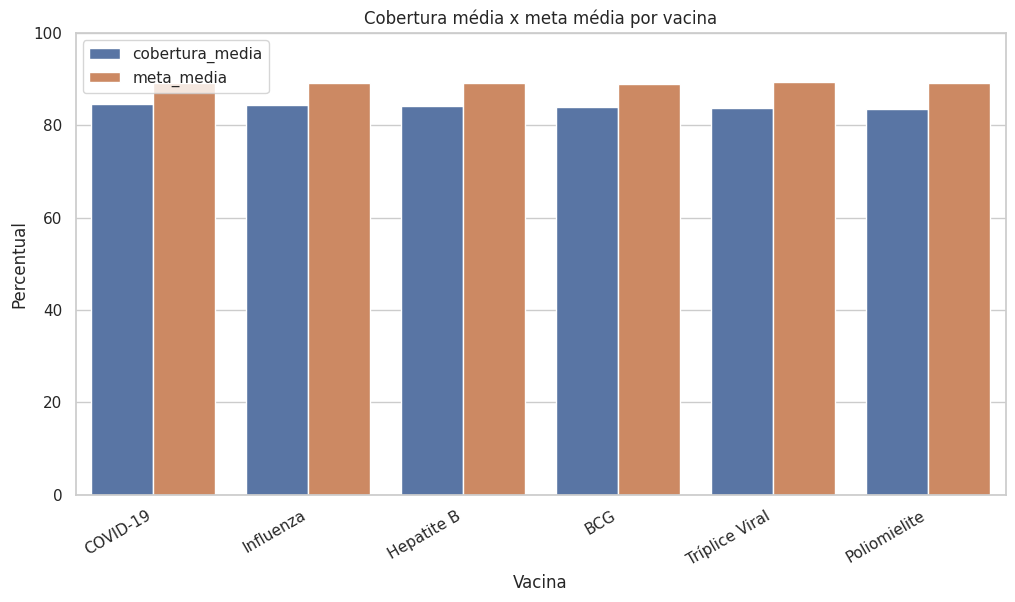

In [24]:
comparacao_vacina = (
    df.groupby("vacina", as_index=False)
      .agg(
          cobertura_media=("cobertura_percentual", "mean"),
          meta_media=("meta_percentual", "mean")
      )
      .sort_values("cobertura_media", ascending=False)
)

comparacao_long = comparacao_vacina.melt(
    id_vars="vacina",
    value_vars=["cobertura_media", "meta_media"],
    var_name="indicador",
    value_name="percentual"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparacao_long,
    x="vacina",
    y="percentual",
    hue="indicador"
)

plt.title("Cobertura média x meta média por vacina")
plt.xlabel("Vacina")
plt.ylabel("Percentual")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.show()

### 9.8 Correlação estatística

A correlação mede associação linear entre variáveis. Ela não comprova causalidade.

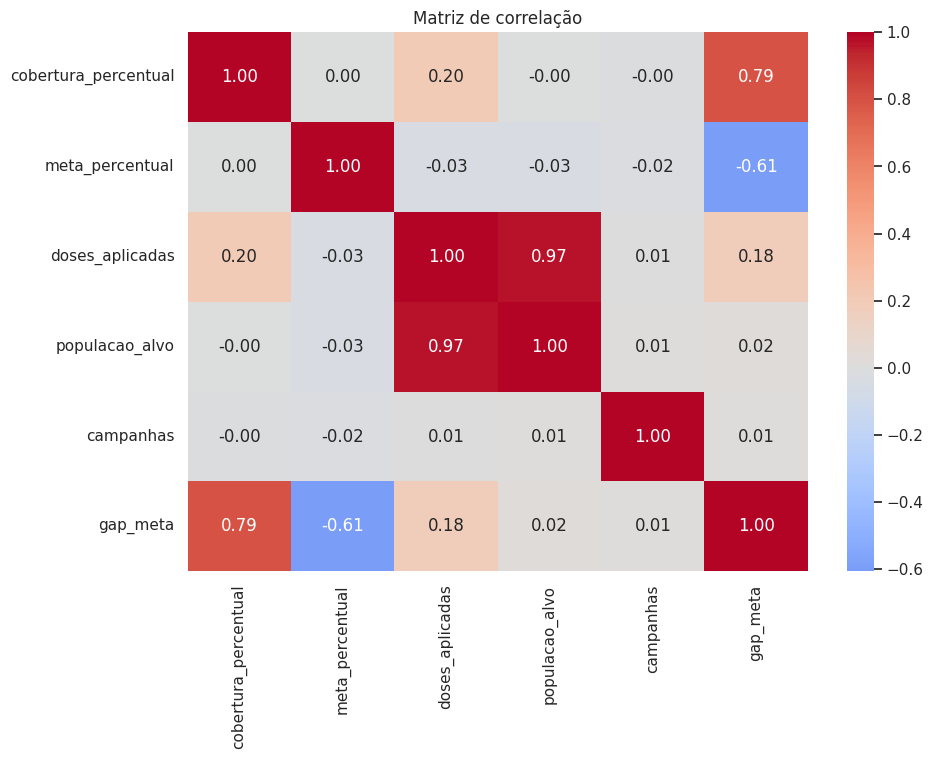

In [25]:
colunas_correlacao = [
    "cobertura_percentual",
    "meta_percentual",
    "doses_aplicadas",
    "populacao_alvo",
    "campanhas",
    "gap_meta"
]

matriz_correlacao = (
    df[colunas_correlacao]
    .corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlação")
plt.show()

## 10. Interpretação dos resultados

A análise da base simulada apresenta os seguintes resultados:

- A base contém **4.440 registros**, de **2015 a 2024**.
- A cobertura média geral é de aproximadamente **84,00%**.
- A mediana da cobertura é de aproximadamente **84,31%**.
- A meta média é de aproximadamente **89,12%**.
- Aproximadamente **34,75% dos registros atingem ou superam sua própria meta**.
- A região **Sul** apresenta a maior cobertura média, aproximadamente **84,77%**.
- A região **Sudeste** apresenta a menor cobertura média, aproximadamente **83,74%**.
- O nível de alerta mais frequente é **Atenção**.
- A série temporal permite observar oscilações ao longo do período.
- A matriz de correlação permite investigar associações lineares entre as variáveis quantitativas.

Todos os resultados devem ser interpretados apenas dentro da base simulada utilizada na atividade.

## 11. Conclusão

O projeto aplicou um fluxo completo de análise de dados com Python: leitura, validação, limpeza, engenharia de atributos, análise exploratória, construção de KPIs, visualizações, análise temporal e correlação estatística.

A base simulada apresenta cobertura média em torno de 84%, abaixo da meta média encontrada no conjunto. Apenas cerca de um terço dos registros alcança sua meta específica.

As diferenças médias entre regiões são pequenas, mas o detalhamento por vacina, período, localidade e nível de alerta permite análises mais específicas.

Como continuidade, a mesma lógica de tratamento será incorporada ao dashboard em **Streamlit**, com filtros interativos, KPIs dinâmicos, tabelas e gráficos.

## 12. Exportação opcional da base tratada

In [26]:
ARQUIVO_SAIDA = "/content/cobertura_vacinal_tratada.csv"

df.to_csv(
    ARQUIVO_SAIDA,
    index=False,
    encoding="utf-8-sig"
)

print(f"Arquivo tratado gerado em: {ARQUIVO_SAIDA}")

Arquivo tratado gerado em: /content/cobertura_vacinal_tratada.csv
